# 02 - Exploratory Data Analysis

ASEAN air quality patterns (real OpenAQ data).

## Questions
1. Which ASEAN cities have the worst air quality?
2. How does Indonesia compare to its neighbors?
3. Are there seasonal patterns?
4. Which cities are improving over time?
5. What does the AQI distribution look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/processed/openaq_clean.parquet')
print(f'Loaded {len(df):,} city-day records')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Countries: {df["country"].unique().tolist()}')
print(f'Cities: {df["city"].nunique()}')

Loaded 10,430 city-day records
Date range: 2021-05-26 to 2026-05-25
Countries: ['Cambodia', 'Indonesia', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']
Cities: 16


## Q1. Which Cities Have the Worst PM2.5?

In [2]:
city_pm25 = df.groupby(['country', 'city'])['pm25'].agg(
    avg=('mean'),
    median=('median'),
    days=('count'),
).reset_index().round(1)
city_pm25 = city_pm25[city_pm25['days'] >= 30].sort_values('avg', ascending=False)

print('Top 20 cities by avg PM2.5:')
print(city_pm25.head(20))

Top 20 cities by avg PM2.5:
        country              city   avg  median  days
1     Indonesia           Bandung  58.1    57.7    52
3     Indonesia             Depok  57.4    57.0   837
14      Vietnam             Hanoi  41.3    33.1   830
7     Indonesia        Yogyakarta  40.5    40.7   205
4     Indonesia           Jakarta  36.7    34.3  1438
6     Indonesia         Palembang  32.2    30.9    78
15      Vietnam  Ho Chi Minh City  30.9    25.8  1132
2     Indonesia             Bogor  28.4    26.8   186
5     Indonesia             Medan  27.2    23.7   145
9       Myanmar            Yangon  26.0    22.5  1452
13     Thailand           Bangkok  22.6    20.0  1666
10  Philippines            Manila  21.6    21.1   362
8      Malaysia      Kuala Lumpur  20.4    15.4   987
12    Singapore         Singapore  19.8    19.0   605
0      Cambodia        Phnom Penh  19.2    18.6   111
11  Philippines       Quezon City  18.3    17.1   341


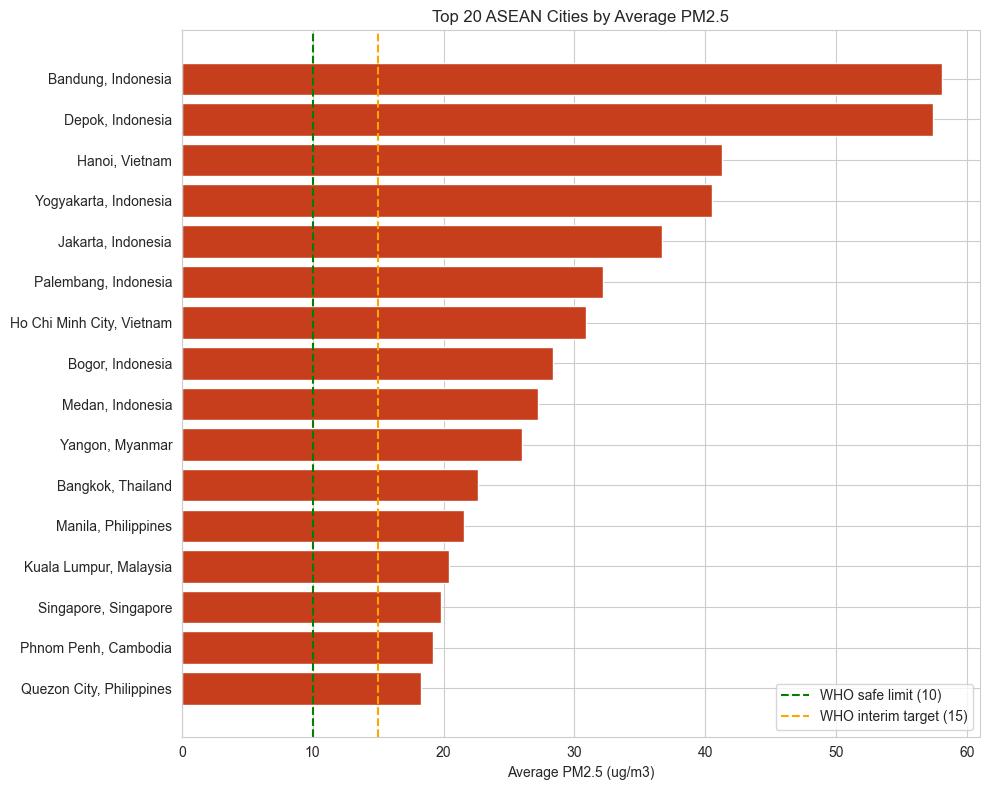

In [3]:
top20 = city_pm25.head(20).copy()
top20['city_country'] = top20['city'].astype(str) + ', ' + top20['country']

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['city_country'], top20['avg'], color='#C73E1D')
ax.set_title('Top 20 ASEAN Cities by Average PM2.5')
ax.set_xlabel('Average PM2.5 (ug/m3)')
ax.axvline(x=10, color='green', linestyle='--', label='WHO safe limit (10)')
ax.axvline(x=15, color='orange', linestyle='--', label='WHO interim target (15)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

### Reliability Check

Some cities have only 1 sensor or limited data. Let's flag which rankings are reliable
(2+ sensors AND 100+ days of data) vs which should be interpreted with caution.

In [4]:
# Add sensor count to the city ranking
# Note: 'df' here is in wide format (after pivot), so we re-load the raw measurements
# to count distinct sensors per city.
from pathlib import Path
raw_files = sorted(Path('../data/raw').glob('openaq_measurements_*.csv'))
raw_df = pd.read_csv(raw_files[-1])

# Re-attach the city info using the locations CSV (same logic as notebook 01)
loc_df = pd.read_csv('../data/raw/asean_locations.csv')
city_lookup = dict(zip(loc_df['id'], loc_df['locality']))
raw_df['city_clean'] = raw_df['location_id'].map(city_lookup).fillna('Unknown')

sensor_counts = raw_df.groupby(['country', 'city_clean'])['location_id'].nunique().reset_index()
sensor_counts.columns = ['country', 'city', 'sensors']
city_pm25_reliable = city_pm25.merge(sensor_counts, on=['country', 'city'], how='left')
city_pm25_reliable['sensors'] = city_pm25_reliable['sensors'].fillna(1).astype(int)

# Reliability: 2+ sensors AND 100+ days
city_pm25_reliable['reliable'] = (
    (city_pm25_reliable['sensors'] >= 2)
    & (city_pm25_reliable['days'] >= 100)
)
city_pm25_reliable['reliability'] = city_pm25_reliable['reliable'].map({
    True: 'Reliable',
    False: 'Limited (single sensor or <100 days)',
})

# Display with reliability
display_cols = ['country', 'city', 'avg', 'days', 'sensors', 'reliability']
print('Top 20 cities with reliability indicator:')
print(city_pm25_reliable[display_cols].head(20).to_string(index=False))

Top 20 cities with reliability indicator:
    country             city  avg  days  sensors                          reliability
  Indonesia          Bandung 58.1    52        1 Limited (single sensor or <100 days)
  Indonesia            Depok 57.4   837        1 Limited (single sensor or <100 days)
    Vietnam            Hanoi 41.3   830        6                             Reliable
  Indonesia       Yogyakarta 40.5   205        2                             Reliable
  Indonesia          Jakarta 36.7  1438       11                             Reliable
  Indonesia        Palembang 32.2    78        3 Limited (single sensor or <100 days)
    Vietnam Ho Chi Minh City 30.9  1132        5                             Reliable
  Indonesia            Bogor 28.4   186        1 Limited (single sensor or <100 days)
  Indonesia            Medan 27.2   145        1 Limited (single sensor or <100 days)
    Myanmar           Yangon 26.0  1452        1 Limited (single sensor or <100 days)
   Thailand 

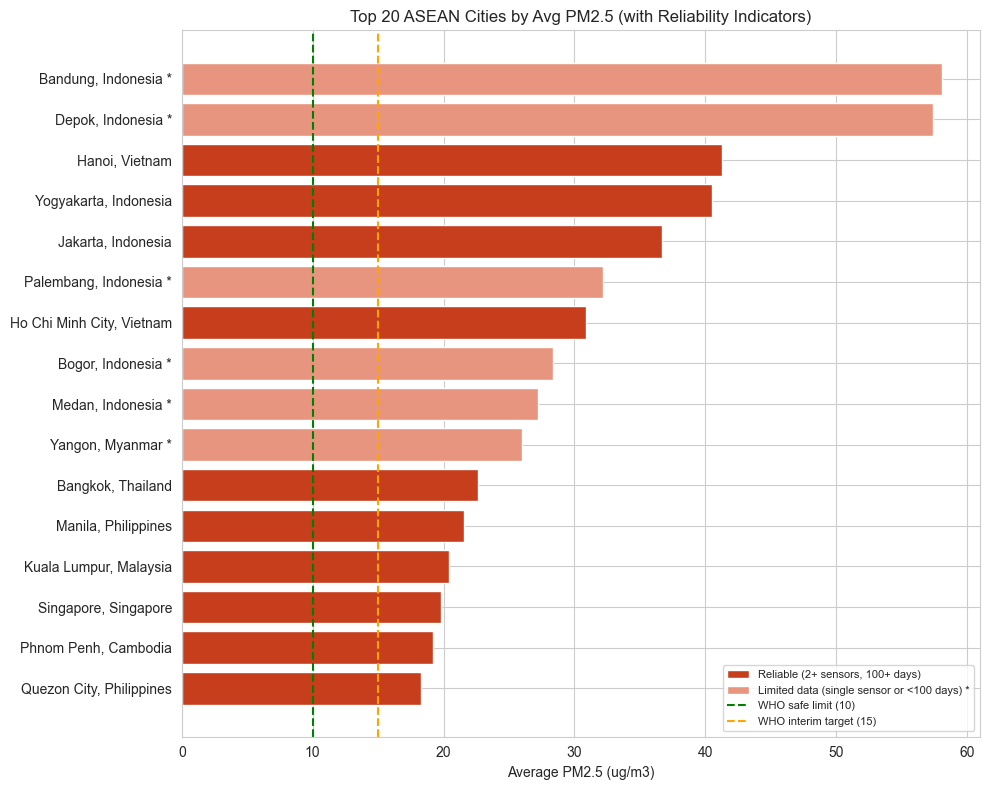

In [5]:
# Re-plot with reliability colors
top20_rel = city_pm25_reliable.head(20).copy()
top20_rel['city_country'] = top20_rel['city'].astype(str) + ', ' + top20_rel['country']
top20_rel.loc[~top20_rel['reliable'], 'city_country'] += ' *'

# Color reliable bars darker, unreliable lighter
colors = ['#C73E1D' if r else '#E89580' for r in top20_rel['reliable']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20_rel['city_country'], top20_rel['avg'], color=colors)
ax.set_title('Top 20 ASEAN Cities by Avg PM2.5 (with Reliability Indicators)')
ax.set_xlabel('Average PM2.5 (ug/m3)')
ax.axvline(x=10, color='green', linestyle='--', label='WHO safe limit (10)')
ax.axvline(x=15, color='orange', linestyle='--', label='WHO interim target (15)')
ax.invert_yaxis()

# Custom legend including reliability note
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C73E1D', label='Reliable (2+ sensors, 100+ days)'),
    Patch(facecolor='#E89580', label='Limited data (single sensor or <100 days) *'),
    plt.Line2D([0], [0], color='green', linestyle='--', label='WHO safe limit (10)'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='WHO interim target (15)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## Q2. Country Comparison

In [6]:
country_stats = df.groupby('country').agg(
    avg_pm25=('pm25', 'mean'),
    median_pm25=('pm25', 'median'),
    avg_pm10=('pm10', 'mean') if 'pm10' in df.columns else ('pm25', 'mean'),
    avg_aqi=('aqi_pm25', 'mean'),
    cities=('city', 'nunique'),
    records=('pm25', 'count'),
).round(1).sort_values('avg_pm25', ascending=False)

print(country_stats)

             avg_pm25  median_pm25  avg_pm10  avg_aqi  cities  records
country                                                               
Indonesia        42.1         40.3      59.4    112.4       7     2941
Vietnam          35.3         28.3      73.1     94.8       2     1962
Myanmar          26.0         22.5       NaN     74.8       1     1452
Thailand         22.6         20.0      36.1     74.5       1     1666
Malaysia         20.4         15.4      31.4     63.8       1      987
Philippines      20.0         19.0       NaN     67.2       2      703
Singapore        19.8         19.0      21.5     66.7       1      605
Cambodia         19.2         18.6       NaN     63.1       1      111


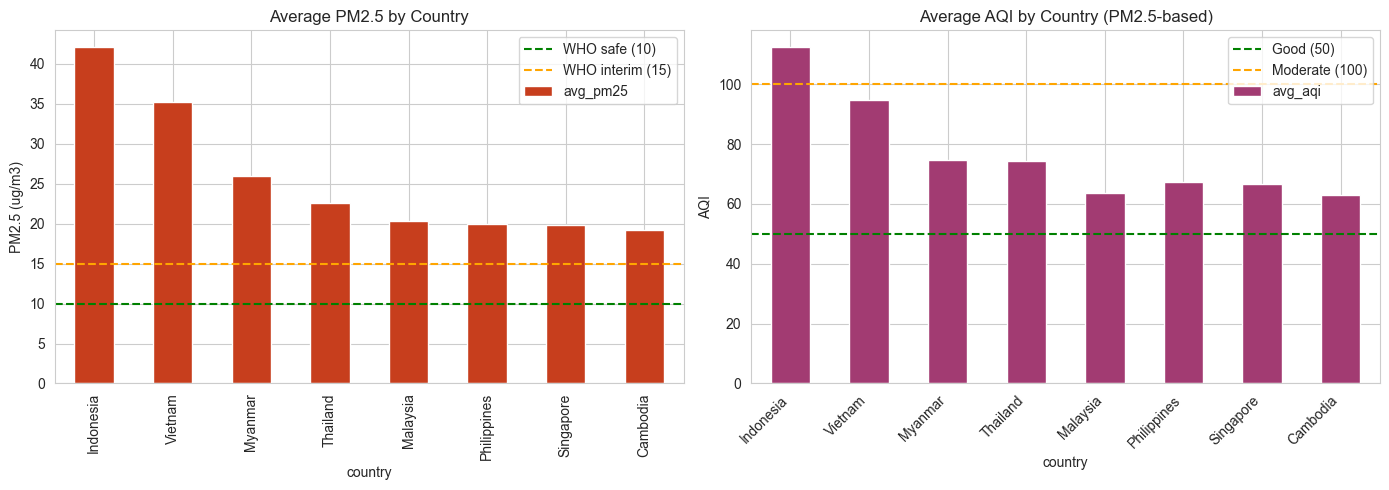

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_stats['avg_pm25'].plot(kind='bar', ax=axes[0], color='#C73E1D')
axes[0].set_title('Average PM2.5 by Country')
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].axhline(y=10, color='green', linestyle='--', label='WHO safe (10)')
axes[0].axhline(y=15, color='orange', linestyle='--', label='WHO interim (15)')
axes[0].legend()

country_stats['avg_aqi'].plot(kind='bar', ax=axes[1], color='#A23B72')
axes[1].set_title('Average AQI by Country (PM2.5-based)')
axes[1].set_ylabel('AQI')
axes[1].axhline(y=50, color='green', linestyle='--', label='Good (50)')
axes[1].axhline(y=100, color='orange', linestyle='--', label='Moderate (100)')
axes[1].legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Q3. Seasonal Patterns

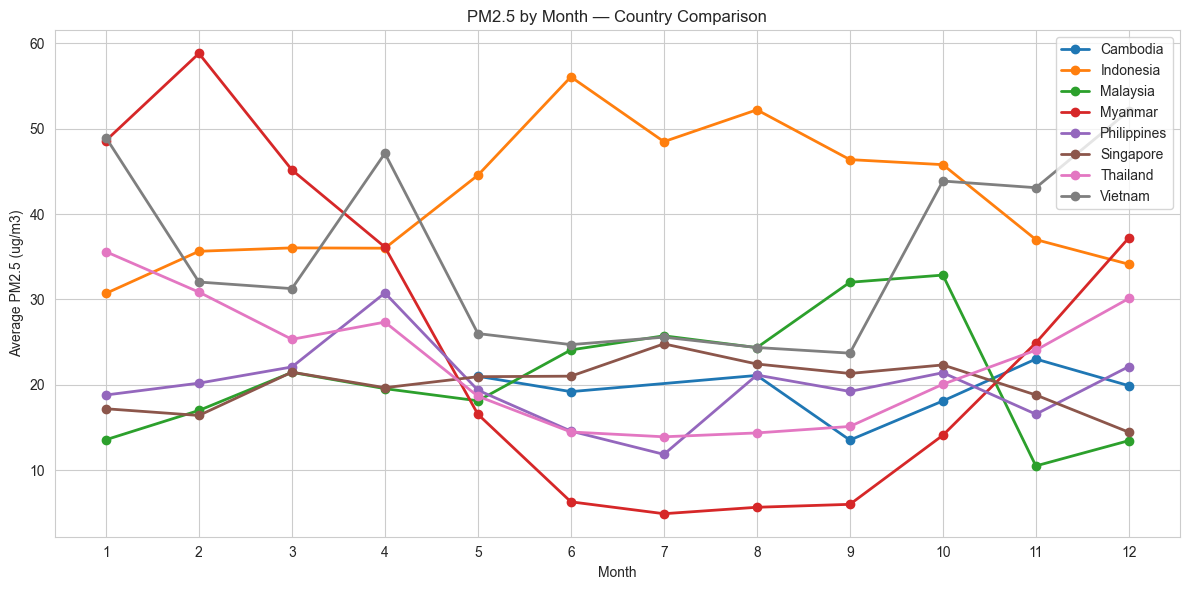

In [8]:
monthly = df.groupby(['country', 'month'])['pm25'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for country in df['country'].unique():
    cd = monthly[monthly['country'] == country]
    ax.plot(cd['month'], cd['pm25'], marker='o', label=country, linewidth=2)
ax.set_title('PM2.5 by Month — Country Comparison')
ax.set_xlabel('Month')
ax.set_ylabel('Average PM2.5 (ug/m3)')
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.show()

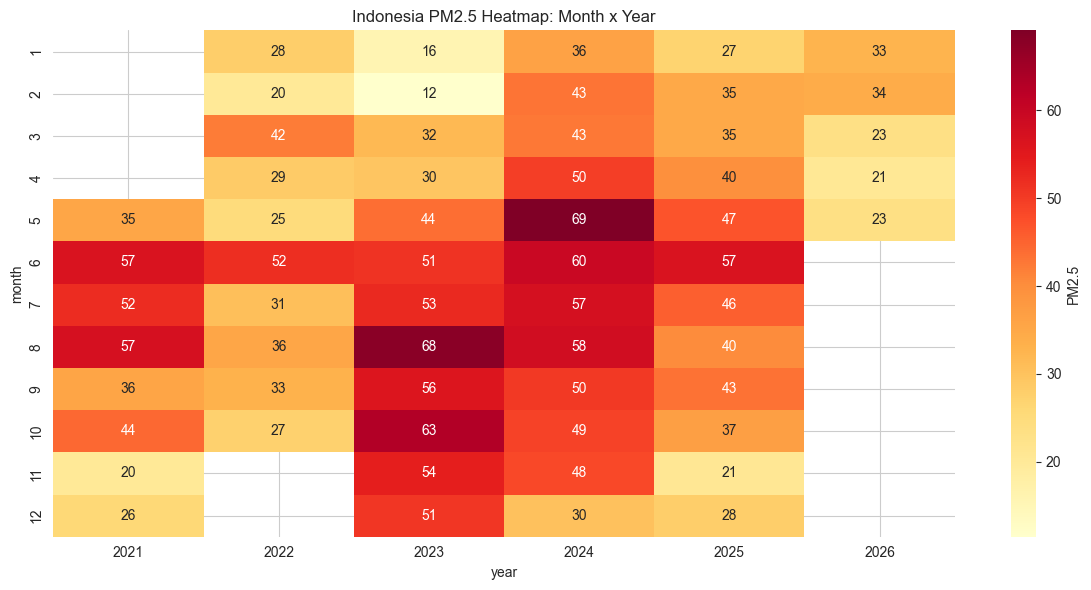

In [9]:
# Indonesia by season heatmap
indo = df[df['country'] == 'Indonesia']
if not indo.empty:
    pivot = indo.pivot_table(values='pm25', index='month', columns='year', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax, cbar_kws={'label': 'PM2.5'})
    ax.set_title('Indonesia PM2.5 Heatmap: Month x Year')
    plt.tight_layout()
    plt.show()

## Q4. Trends Over Time

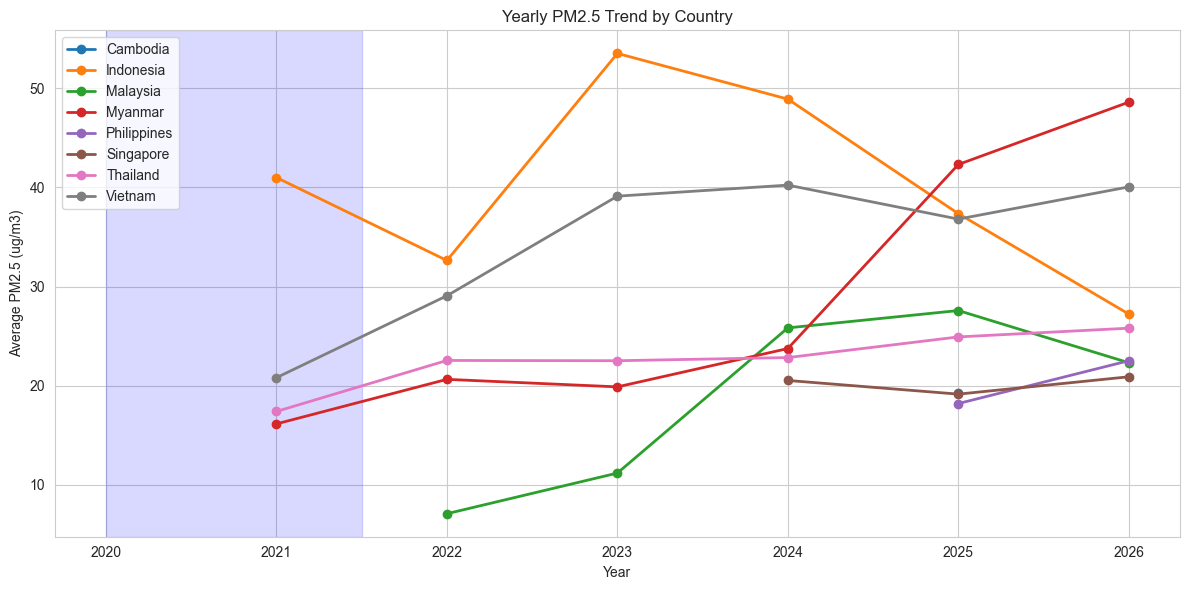

In [10]:
yearly = df.groupby(['country', 'year'])['pm25'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for country in df['country'].unique():
    cd = yearly[yearly['country'] == country]
    ax.plot(cd['year'], cd['pm25'], marker='o', label=country, linewidth=2)
ax.set_title('Yearly PM2.5 Trend by Country')
ax.set_xlabel('Year')
ax.set_ylabel('Average PM2.5 (ug/m3)')
ax.legend()
ax.axvspan(2020, 2021.5, alpha=0.15, color='blue', label='COVID')
plt.tight_layout()
plt.show()

## Q5. AQI Distribution

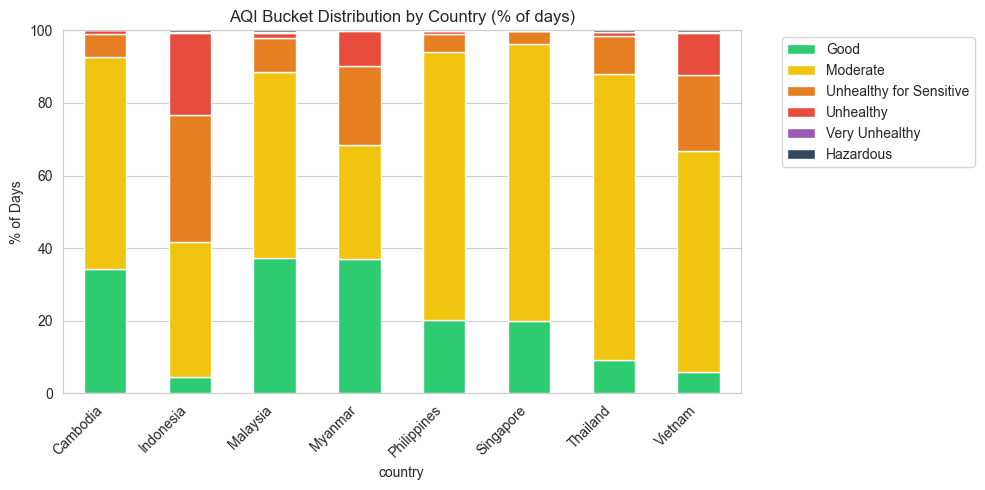


Days in each AQI bucket per country:
aqi_bucket   Good  Moderate  Unhealthy for Sensitive  Unhealthy  \
country                                                           
Cambodia     34.2      58.6                      6.3        0.9   
Indonesia     4.4      37.2                     35.2       22.7   
Malaysia     37.4      51.3                      9.2        1.3   
Myanmar      37.0      31.5                     21.8        9.4   
Philippines  20.1      74.1                      5.0        0.6   
Singapore    19.8      76.4                      3.6        0.0   
Thailand      9.1      78.9                     10.5        1.3   
Vietnam       5.8      61.1                     20.9       11.5   

aqi_bucket   Very Unhealthy  Hazardous  
country                                 
Cambodia                0.0        0.0  
Indonesia               0.1        0.4  
Malaysia                0.4        0.4  
Myanmar                 0.3        0.0  
Philippines             0.0        0.3  
Sing

In [11]:
if 'aqi_bucket' in df.columns:
    bucket_order = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
    bucket_data = df.groupby(['country', 'aqi_bucket']).size().unstack(fill_value=0)
    bucket_data = bucket_data[[c for c in bucket_order if c in bucket_data.columns]]
    bucket_pct = bucket_data.div(bucket_data.sum(axis=1), axis=0) * 100

    colors = {
        'Good': '#2ecc71', 'Moderate': '#f1c40f',
        'Unhealthy for Sensitive': '#e67e22', 'Unhealthy': '#e74c3c',
        'Very Unhealthy': '#9b59b6', 'Hazardous': '#34495e',
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    bucket_pct.plot(kind='bar', stacked=True, ax=ax,
                    color=[colors.get(c, '#666') for c in bucket_pct.columns])
    ax.set_title('AQI Bucket Distribution by Country (% of days)')
    ax.set_ylabel('% of Days')
    ax.legend(bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('\nDays in each AQI bucket per country:')
    print(bucket_pct.round(1))

## Indonesia Deep Dive

In [12]:
indo_cities = df[df['country'] == 'Indonesia'].groupby('city').agg(
    avg_pm25=('pm25', 'mean'),
    avg_aqi=('aqi_pm25', 'mean'),
    days=('pm25', 'count'),
).round(1).sort_values('avg_pm25', ascending=False)
indo_cities = indo_cities[indo_cities['days'] >= 30]
print('Indonesian cities by PM2.5:')
print(indo_cities)

Indonesian cities by PM2.5:
            avg_pm25  avg_aqi  days
city                               
Bandung         58.1    145.2    52
Depok           57.4    139.1   837
Yogyakarta      40.5    112.8   205
Jakarta         36.7    103.0  1438
Palembang       32.2     98.5    78
Bogor           28.4     84.9   186
Medan           27.2     82.5   145
